# Setup

In [1]:
# base
import os
import sys
import warnings
import logging
import pickle
from pathlib import Path

# data manipulation
import pickle
import pandas as pd
import itables
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

# single cell
import scanpy as sc

itables.init_notebook_mode(connected=True)  # Use connected=False for offline use
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", pd.errors.DtypeWarning)
warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
warnings.simplefilter("ignore", DeprecationWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.ERROR)
mlogger = logging.getLogger("harmonypy")
mlogger.setLevel(logging.ERROR)

# custom
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

from rpy2.robjects.conversion import localconverter

converter = get_converter()

# R_preload()
%load_ext rpy2.ipython

study = "Jaitlin2019"

CORES = 10
DATADIR = Path("../../../data")
REFDIR = Path("../../../references")
DOUBLETMETHODS = ["scDblFinder", "DoubletFinder", "doubletdetection", "scrublet"]

%matplotlib inline
mpl.rcdefaults()

/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


# Access & Preprocess adata

In [56]:
study_name = "Jaitlin2019_download"
experiment_dir = Path(DATADIR / "counts" / study_name)

adatas = {}
for filename in os.listdir(experiment_dir):
    if filename.endswith("txt"):
        sample = filename.split("_")[0]
        adatas[sample] = sc.AnnData(pd.read_csv(experiment_dir / filename, sep="\t").T)
        adatas[sample].X = scipy.sparse.csr_matrix(adatas[sample].X)

In [74]:
# get metadata
GENERATE_METADATA = False

if GENERATE_METADATA is True:
    import requests
    from bs4 import BeautifulSoup
    import csv

    base_link = "https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc="
    sample_ids = list(adatas.keys())
    metadata_filename = (
        DATADIR / "counts" / "Jaitlin2019_download" / "GSE128518_metadata.csv"
    )

    with open(metadata_filename, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["Sample", "Age", "Diet", "Depot", "HFD Length"])

        for sample in sample_ids:
            r = requests.get(base_link + sample)
            soup = BeautifulSoup(r.text, "html.parser")
            chars = soup.find("td", text="Characteristics")
            # parse text within "Characteristics"
            block = chars.find_next_sibling("td")
            texts = list(block.stripped_strings)

            age = ""
            diet = ""
            depot = ""
            for line in texts:
                if "mouse age (weeks)" in line:
                    age = line.split(":")[1].strip()
                elif "treatment (diet)" in line:
                    diet = line.split(":")[1].strip()
                elif "tissue subtype" in line:
                    depot = line.split(":")[1].strip()
                elif "time point (weeks)" in line:
                    diet_start = line.split(":")[1].strip()

            # infer HFD length if diet contains "High-fat"
            hfd_len = ""
            if "High-fat" in diet:
                start = int(age) - int(diet_start)
                hfd_len = str(start) + " weeks"
            else:
                hfd_len = "not applicable"

            w.writerow([sample, age + " weeks", diet, depot, hfd_len])
            adatas[sample].obs["Identifier"] = sample
            adatas[sample].obs["Age"] = age + " weeks"
            adatas[sample].obs["Diet"] = diet
            adatas[sample].obs["Depot"] = depot
            adatas[sample].obs["HFD Length"] = hfd_len

    metadata = pd.read_csv(metadata_filename)
else:
    metadata = pd.read_csv(
        DATADIR / "counts" / "Jaitlin2019_download" / "GSE128518_metadata.csv"
    )
    metadata = metadata.fillna("not applicable")
    for sample in list(adatas.keys()):
        dat = metadata[metadata["Sample"] == sample]
        adatas[sample].obs["Identifier"] = dat["Sample"].tolist()[0]
        adatas[sample].obs["Age"] = dat["Age"].tolist()[0]
        adatas[sample].obs["Diet"] = dat["Diet"].tolist()[0]
        adatas[sample].obs["Depot"] = dat["Depot"].tolist()[0]
        adatas[sample].obs["HFD Length"] = dat["HFD Length"].tolist()[0]

metadata

Loading ITables v2.6.2 from the internet... (need help?)


In [ ]:
adata = sc.concat(adatas, join="outer")
print(adata)
adata = Filter_QC(adata, GenePerCell=250, CountPerCell=500, CellPerGene=0)
adata = Filter_GeneGroup(adata, perc_threshold=10, verbose=True)
adata.layers["counts"] = adata.X.copy()
adata

AnnData object with n_obs × n_vars = 57600 × 52634
    obs: 'Identifier', 'Age', 'Diet', 'Depot', 'HFD Length'
Cells removed by gene/count filters: 16645 (28.90%)
Cells with >10% mito genes: 29640 (72.37%)


In [100]:
for method in tqdm(DOUBLETMETHODS):
    Filter_Doublet(adata, method, remove=False)
adata

  0%|          | 0/4 [00:00<?, ?it/s]2026-01-20 11:43:03 | [WARNING] R callback write-console: Creating ~9052 artificial doublets...
  
2026-01-20 11:43:20 | [WARNING] R callback write-console: Dimensional reduction
  
2026-01-20 11:43:29 | [WARNING] R callback write-console: Evaluating kNN...
  
2026-01-20 11:43:44 | [WARNING] R callback write-console: Training model...
  
2026-01-20 11:43:44 | [WARNING] R callback write-console: iter=0, 1290 cells excluded from training.
  
2026-01-20 11:44:17 | [WARNING] R callback write-console: iter=1, 1582 cells excluded from training.
  
2026-01-20 11:44:52 | [WARNING] R callback write-console: iter=2, 1645 cells excluded from training.
  
2026-01-20 11:45:21 | [WARNING] R callback write-console: Threshold found:0.481
  
2026-01-20 11:45:21 | [WARNING] R callback write-console: 1320 (11.7%) doublets called
  
 25%|██▌       | 1/4 [02:52<08:38, 172.90s/it]

0        singlet
1        singlet
2        singlet
3        singlet
4        singlet
          ...   
11310    singlet
11311    singlet
11312    singlet
11313    singlet
11314    singlet
Length: 11315, dtype: object


2026-01-20 11:45:43 | [WARNING] R callback write-console: Renaming default assay from originalexp to RNA
  
2026-01-20 11:45:43 | [WARNING] R callback write-console: Performing log-normalization
  
2026-01-20 11:45:43 | [WARNING] R callback write-console: 0%   10   20   30   40   50   60   70   80   90   100%
  
2026-01-20 11:45:43 | [WARNING] R callback write-console: [----|----|----|----|----|----|----|----|----|----|
  
2026-01-20 11:45:43 | [WARNING] R callback write-console: *  
2026-01-20 11:45:43 | [WARNING] R callback write-console: *  
2026-01-20 11:45:43 | [WARNING] R callback write-console: *  
2026-01-20 11:45:43 | [WARNING] R callback write-console: *  
2026-01-20 11:45:43 | [WARNING] R callback write-console: *  
2026-01-20 11:45:43 | [WARNING] R callback write-console: *  
2026-01-20 11:45:43 | [WARNING] R callback write-console: *  
2026-01-20 11:45:43 | [WARNING] R callback write-console: *  
2026-01-20 11:45:43 | [WARNING] R callback write-console: *  
2026-01-20 11:4

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 11315
Number of edges: 411219

Running Louvain algorithm...


2026-01-20 11:46:23 | [WARNING] R callback write-console: 0%   10   20   30   40   50   60   70   80   90   100%
  
2026-01-20 11:46:23 | [WARNING] R callback write-console: [----|----|----|----|----|----|----|----|----|----|
  
2026-01-20 11:46:23 | [WARNING] R callback write-console: *  
2026-01-20 11:46:23 | [WARNING] R callback write-console: *  
2026-01-20 11:46:23 | [WARNING] R callback write-console: *  
2026-01-20 11:46:23 | [WARNING] R callback write-console: *  
2026-01-20 11:46:23 | [WARNING] R callback write-console: *  
2026-01-20 11:46:23 | [WARNING] R callback write-console: *  
2026-01-20 11:46:23 | [WARNING] R callback write-console: *  
2026-01-20 11:46:23 | [WARNING] R callback write-console: *  
2026-01-20 11:46:23 | [WARNING] R callback write-console: *  
2026-01-20 11:46:23 | [WARNING] R callback write-console: *  
2026-01-20 11:46:24 | [WARNING] R callback write-console: *  
2026-01-20 11:46:24 | [WARNING] R callback write-console: *  
2026-01-20 11:46:24 | [WARN

...

[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Computing pANN..."
[1] "Classifying doublets.."


2026-01-20 11:52:08 | [WARNING] R callback write-console: In addition:   
2026-01-20 11:52:08 | [WARNING] R callback write-console: Warning message:
  
2026-01-20 11:52:08 | [WARNING] R callback write-console: Key ‘originalexp_’ taken, using ‘rna_’ instead 
  
 50%|█████     | 2/4 [09:39<10:20, 310.44s/it]

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 4/4 [13:30<00:00, 202.75s/it]


AnnData object with n_obs × n_vars = 11315 × 23835
    obs: 'Identifier', 'Age', 'Diet', 'Depot', 'HFD Length', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'predicted_doublet-scDblFinder', 'doublet_score-scDblFinder', 'predicted_doublet-DoubletFinder', 'doublet_score-DoubletFinder', 'predicted_doublet-doubletdetection', 'doublet_score-doubletdetection', 'predicted_doublet-scrublet', 'doublet_score-scrublet'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mito'
    uns: 'methods', 'scrublet'
    layers: 'counts'

... storing 'Identifier' as categorical
... storing 'Age' as categorical
... storing 'Diet' as categorical
... storing 'Depot' as categorical
... storing 'HFD Length' as categorical


Finding HVGs...
Staring PCA with gene mask highly_variable at 50 comps, saved at .obsm[PCA_hvg]


2026-01-20 12:25:09,943 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-01-20 12:25:09 | [INFO] Running Harmony (PyTorch on cpu)
2026-01-20 12:25:09,946 - harmonypy - INFO -   Parameters:
2026-01-20 12:25:09 | [INFO]   Parameters:
2026-01-20 12:25:09,947 - harmonypy - INFO -     max_iter_harmony: 10
2026-01-20 12:25:09 | [INFO]     max_iter_harmony: 10
2026-01-20 12:25:09,949 - harmonypy - INFO -     max_iter_kmeans: 20
2026-01-20 12:25:09 | [INFO]     max_iter_kmeans: 20
2026-01-20 12:25:09,951 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-01-20 12:25:09 | [INFO]     epsilon_cluster: 1e-05
2026-01-20 12:25:09,952 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-01-20 12:25:09 | [INFO]     epsilon_harmony: 0.0001
2026-01-20 12:25:09,953 - harmonypy - INFO -     nclust: 100
2026-01-20 12:25:09 | [INFO]     nclust: 100
2026-01-20 12:25:09,955 - harmonypy - INFO -     block_size: 0.05
2026-01-20 12:25:09 | [INFO]     block_size: 0.05
2026-01-20 12:25:09,958 - harmon

Integrating by Column Identifier: ['GSM3678454', 'GSM3678461', 'GSM3678350', 'GSM3678465', 'GSM3678427', ..., 'GSM3678425', 'GSM3678360', 'GSM3678467', 'GSM3678485', 'GSM3678480']
Length: 150
Categories (150, object): ['GSM3678314', 'GSM3678315', 'GSM3678320', 'GSM3678321', ..., 'GSM3678482', 'GSM3678483', 'GSM3678484', 'GSM3678485']


2026-01-20 12:25:10,501 - harmonypy - INFO - KMeans initialization complete.
2026-01-20 12:25:10 | [INFO] KMeans initialization complete.
2026-01-20 12:25:10,522 - harmonypy - INFO - Iteration 1 of 10
2026-01-20 12:25:10 | [INFO] Iteration 1 of 10
2026-01-20 12:25:20,856 - harmonypy - INFO - Iteration 2 of 10
2026-01-20 12:25:20 | [INFO] Iteration 2 of 10
2026-01-20 12:25:32,008 - harmonypy - INFO - Iteration 3 of 10
2026-01-20 12:25:32 | [INFO] Iteration 3 of 10
2026-01-20 12:25:42,410 - harmonypy - INFO - Iteration 4 of 10
2026-01-20 12:25:42 | [INFO] Iteration 4 of 10
2026-01-20 12:25:52,483 - harmonypy - INFO - Iteration 5 of 10
2026-01-20 12:25:52 | [INFO] Iteration 5 of 10
2026-01-20 12:26:02,110 - harmonypy - INFO - Iteration 6 of 10
2026-01-20 12:26:02 | [INFO] Iteration 6 of 10
2026-01-20 12:26:11,648 - harmonypy - INFO - Iteration 7 of 10
2026-01-20 12:26:11 | [INFO] Iteration 7 of 10
2026-01-20 12:26:21,078 - harmonypy - INFO - Iteration 8 of 10
2026-01-20 12:26:21 | [INFO] 

Starting UMAP...


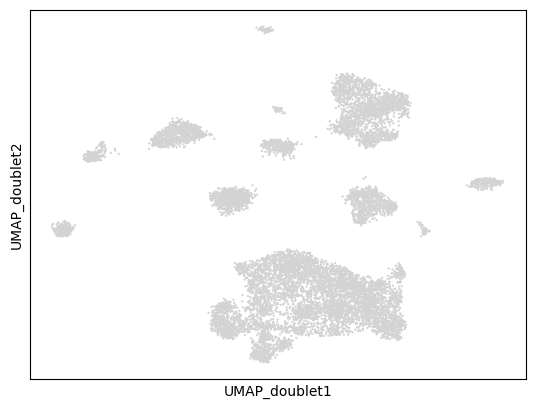

Starting LocalMAP...


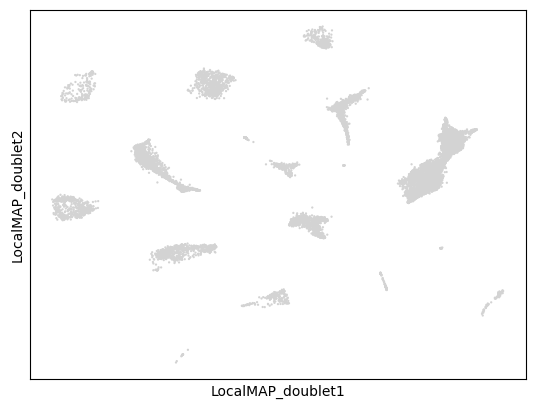

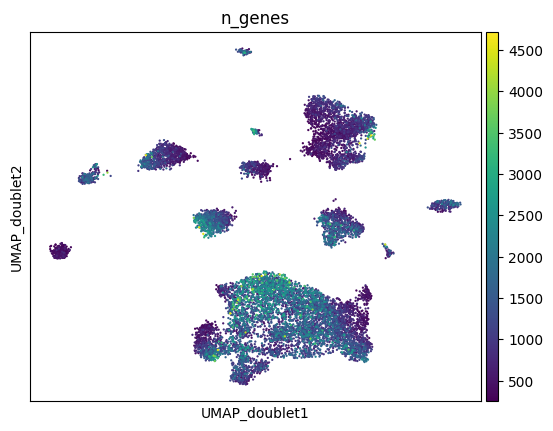

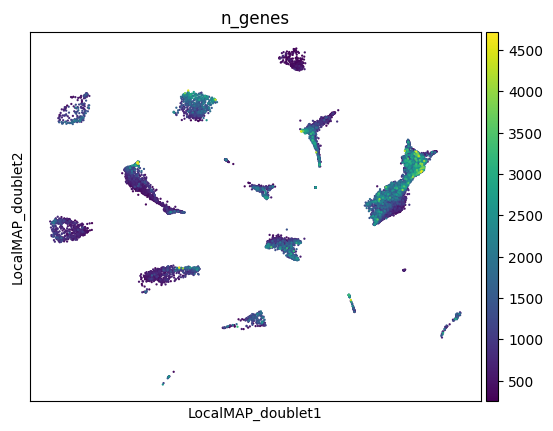

100%|██████████| 3/3 [00:15<00:00,  5.13s/it]


AnnData object with n_obs × n_vars = 11315 × 23835
    obs: 'Identifier', 'Age', 'Diet', 'Depot', 'HFD Length', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'predicted_doublet-scDblFinder', 'doublet_score-scDblFinder', 'predicted_doublet-DoubletFinder', 'doublet_score-DoubletFinder', 'predicted_doublet-doubletdetection', 'doublet_score-doubletdetection', 'predicted_doublet-scrublet', 'doublet_score-scrublet', 'leiden_doublets_0.5', 'leiden_doublets_0.7', 'leiden_doublets_1.0'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mito', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'methods', 'scrublet', 'log1p', 'hvg', 'PCA_hvg', 'neighbors_doublet', 'UMAP_do

In [120]:
batch_column = "Identifier"
hvg_kind = "seurat"
int_kind = "harmony"
pca_key = "PCA_hvg"
neighbors_key = "neighbors_doublet"
key = "leiden_doublets"

Normalize(adata, kind="log1p", batch_column=batch_column)
FindVariableGenes(adata, kind=hvg_kind, batch_column=batch_column)
PCA(adata, key=pca_key)
Integrate(adata, pca_key=pca_key, kind=int_kind, batch_column=batch_column)
Visualize(adata, key="doublet")

sc.pl.embedding(adata, basis="UMAP_doublet", color="n_genes")
sc.pl.embedding(adata, basis="LocalMAP_doublet", color="n_genes")

Cluster(adata, key, [0.5, 0.7, 1.0], neighbor_key=neighbors_key)

adata.write(DATADIR / "processed" / "single_cell" / study / "has_doublets.h5ad")
adata

# Load and Clean

In [ ]:
adata = sc.read_h5ad(
    DATADIR / "processed" / "single_cell" / study / "has_doublets.h5ad"
)

predicted_doublet-scDblFinder         1320
predicted_doublet-DoubletFinder        780
predicted_doublet-doubletdetection    3014
predicted_doublet-scrublet               2
dtype: int64


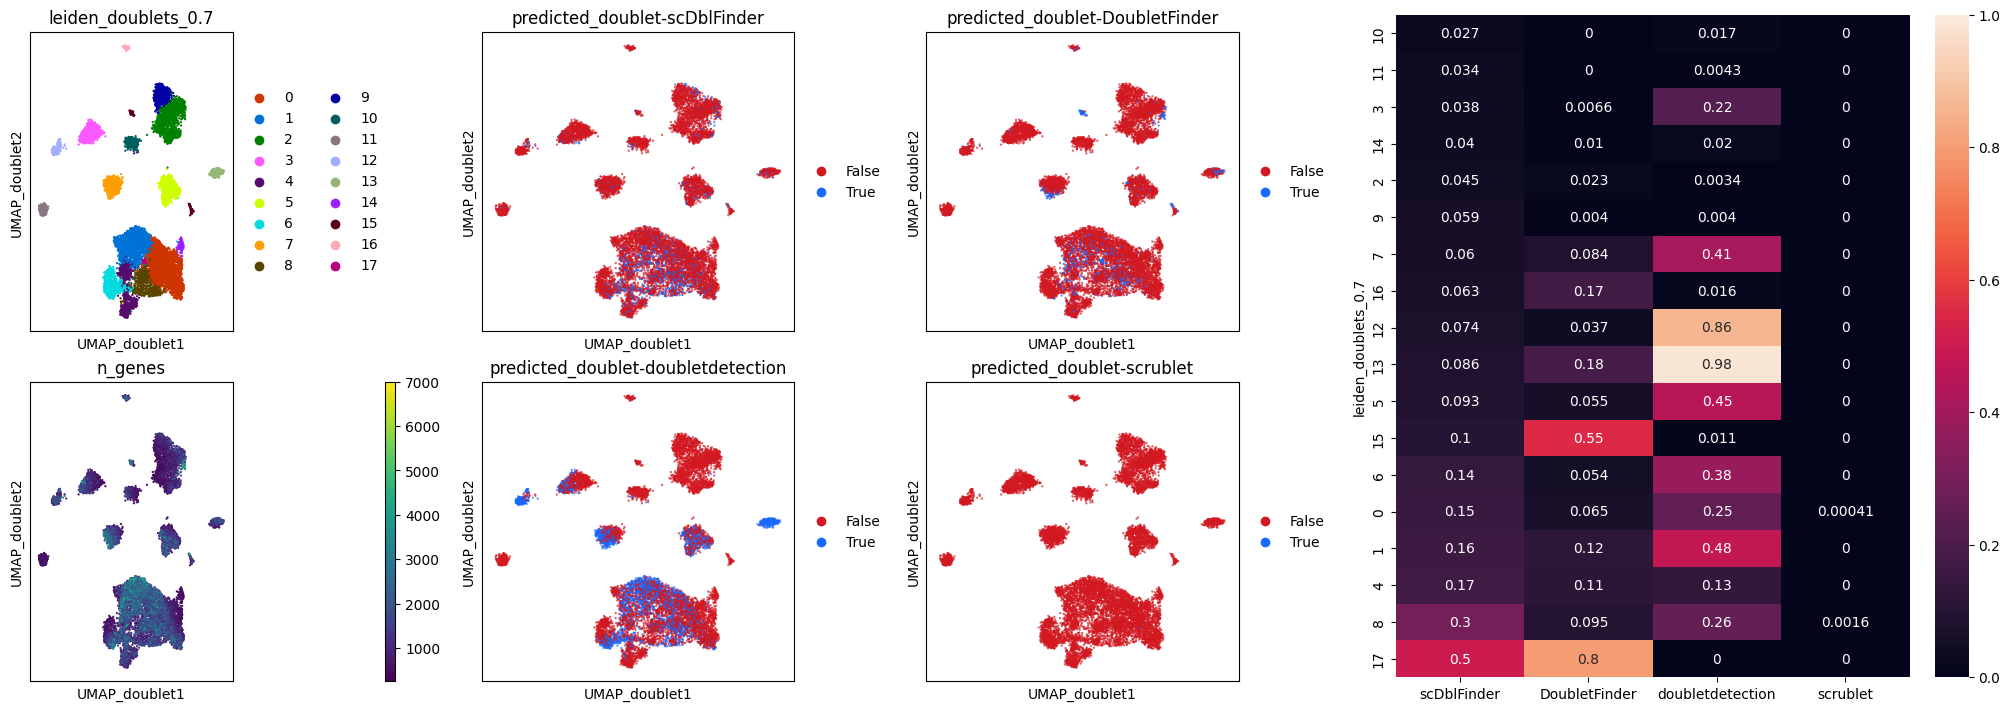

In [128]:
key = "leiden_doublets"
resolution = 0.7
cluster_key = f"{key}_{resolution:.1f}"
embedding = "UMAP_doublet"

check_doublets(adata, embedding, cluster_key)
print(adata.obs[[f"predicted_doublet-{m}" for m in DOUBLETMETHODS]].sum(axis=0))

1147


Text(0.02, 0.02, 'n = 11315')

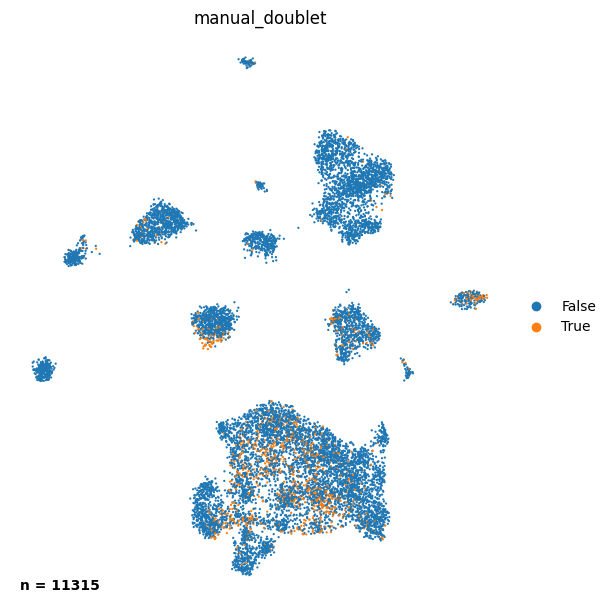

In [131]:
multi_doublet = adata.obs[[f"predicted_doublet-{m}" for m in DOUBLETMETHODS]].sum(
    axis=1
)

# doublet_clusters = pd.Series([11, 15, 16, 23, 21, 26, 14, 28]).astype(str)
adata.obs["manual_doublet"] = multi_doublet >= 2
print(adata.obs["manual_doublet"].sum())

f, ax = plt.subplots(1, 1, layout="constrained", figsize=(6, 6))
sc.pl.embedding(
    adata, basis=embedding, color="manual_doublet", frameon=False, ax=ax, show=False
)
ax.annotate(
    f"n = {adata.shape[0]}",
    (0.02, 0.02),
    fontweight="bold",
    fontsize=10,
    xycoords="axes fraction",
)

In [ ]:
adata.obs_names = generate_barcodes(adata.shape[0])

In [7]:
# save
annotation = "doublet_cleaned"
adata[~adata.obs["manual_doublet"]].write(
    DATADIR / "processed" / "single_cell" / study / f"{annotation}.h5ad"
)

In [ ]:
adata = sc.read_h5ad(
    DATADIR / "processed" / "single_cell" / study / f"{annotation}.h5ad"
)